# EMG Conformer CTC v8 — published-aligned architecture

Aligns with standard Conformer implementation while keeping your hyperparameters.

**Changes from v3:**
- Relative positional encoding (Transformer-XL style, learnable u/v bias)
- Per-hand projection: left and right 16ch projected independently (proj_dim=64),
  concatenated and fused into d_model=128
- BatchNorm in ConvolutionModule (per original Conformer paper)
- Best checkpoint saved on val CER, not val loss
- SpecAugment applied independently to each hand

**Kept from v3:** CHUNK=256, lr=1e-3, weight_decay=1e-4, d_model=128,
n_heads=4, n_layers=4, dropout=0.3, grad_clip=1.0, charset.py vocab, YAML split


## 1. Install Dependencies
Install required packages (`h5py`, `unidecode`) if not already present.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], check=True)

CompletedProcess(args=['/Users/jonathangray/miniconda3/envs/e219/bin/python', '-m', 'pip', 'install', '-q', 'h5py', 'unidecode'], returncode=0)

## 2. Imports & Device Setup
Import standard libraries, PyTorch, and the `emg2qwerty` charset. Detect CPU/GPU device.

In [2]:
import sys
sys.path.insert(0, '..')

import h5py
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

from emg2qwerty.charset import charset as get_charset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHARSET = get_charset()
print('device:', device)

device: cpu


## 3. Session Configuration & Data Loading
Define train/val/test session IDs, resolve HDF5 file paths, set chunk size, and load/normalize EMG chunks with keystroke labels.

In [ ]:
# Conformer CTC v6 — published-aligned architecture, your hyperparameters
import sys
sys.path.insert(0, '..')

import h5py, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import matplotlib.pyplot as plt

from emg2qwerty.charset import charset as get_charset

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHARSET = get_charset()
print('device:', device)
print(f'Charset: {len(CHARSET)} keys, {CHARSET.num_classes} classes (blank={CHARSET.null_class})')

SESSION_DIR = Path('89335547')
SUFFIX      = '_recons_v3.hdf5'

blank_id    = CHARSET.null_class
num_classes = CHARSET.num_classes

TRAIN_SESSIONS = [
    '2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-03-1622764398-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-21-1626917264-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-05-1622889105-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-03-1622766673-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-04-1622861066-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-22-1627001995-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-06-05-1622884635-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
    '2021-07-21-1626915176-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
]
VAL_SESSIONS = [
    '2021-06-04-1622862148-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
]
TEST_SESSIONS = [
    '2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f',
]

train_files = [SESSION_DIR / (s + SUFFIX) for s in TRAIN_SESSIONS]
val_files   = [SESSION_DIR / (s + SUFFIX) for s in VAL_SESSIONS]
test_files  = [SESSION_DIR / (s + SUFFIX) for s in TEST_SESSIONS]

for f in train_files + val_files + test_files:
    assert f.exists(), f'Missing: {f}'

CHUNK   = 256
RATE_HZ = 2000 / 64

# Load + chunk (left and right hands kept separate)
def load_chunks(file_list):
    X_left, X_right, tgt = [], [], []
    for f_path in file_list:
        with h5py.File(f_path) as f:
            times      = f['emg2qwerty/timeseries/time'][:]
            emg_left   = f['emg2qwerty/timeseries/emg_left'][:]
            emg_right  = f['emg2qwerty/timeseries/emg_right'][:]
            keystrokes = json.loads(f['emg2qwerty'].attrs['keystrokes'])
        left  = emg_left.astype(np.float32)
        right = emg_right.astype(np.float32)
        left  = (left  - left.mean(0,  keepdims=True)) / (left.std(0,  keepdims=True) + 1e-8)
        right = (right - right.mean(0, keepdims=True)) / (right.std(0, keepdims=True) + 1e-8)
        keys_sorted = sorted(keystrokes, key=lambda k: k['start'])
        for start in range(0, len(left) - CHUNK + 1, CHUNK):
            end        = start + CHUNK
            t0_chunk   = times[start]
            t1_chunk   = times[end - 1] + 1.0 / RATE_HZ
            chunk_keys = [k for k in keys_sorted
                          if t0_chunk <= k['start'] < t1_chunk and k.get('key') in CHARSET]
            X_left.append(left[start:end])
            X_right.append(right[start:end])
            tgt.append(torch.tensor([CHARSET.key_to_label(k['key']) for k in chunk_keys],
                                    dtype=torch.long))
    return (torch.tensor(np.array(X_left),  dtype=torch.float32),
            torch.tensor(np.array(X_right), dtype=torch.float32),
            tgt)

Xl_train, Xr_train, tgt_train = load_chunks(train_files)
Xl_val,   Xr_val,   tgt_val   = load_chunks(val_files)
Xl_test,  Xr_test,  tgt_test  = load_chunks(test_files)

print(f'Chunks — train: {len(Xl_train)}  val: {len(Xl_val)}  test: {len(Xl_test)}')
print(f'Avg keys/chunk: {np.mean([len(t) for t in tgt_train + tgt_val]):.1f}')


device: cpu
Charset: 98 keys, 99 classes (blank=98)
Chunks — train: 3744  val: 207  test: 274
Avg keys/chunk: 19.6
Params: 1,635,651



## 4. SpecAugment Data Augmentation
Apply random time and channel masking plus Gaussian noise independently to each hand during training.

In [ ]:
# SpecAugment (applied per-hand independently)
class SpecAugment(nn.Module):
    def __init__(self, T_masks=2, T_width=20, C_masks=1, C_width=4, noise_std=0.05):
        super().__init__()
        self.T_masks = T_masks; self.T_width = T_width
        self.C_masks = C_masks; self.C_width = C_width
        self.noise_std = noise_std

    def forward(self, x):
        if not self.training: return x
        B, T, C = x.shape
        x = x.clone()
        for _ in range(self.T_masks):
            w = torch.randint(1, self.T_width + 1, (1,)).item()
            t = torch.randint(0, max(1, T - w), (B,))
            for b in range(B): x[b, t[b]:t[b]+w, :] = 0.0
        for _ in range(self.C_masks):
            w = torch.randint(1, self.C_width + 1, (1,)).item()
            c = torch.randint(0, max(1, C - w), (1,)).item()
            x[:, :, c:c+w] = 0.0
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x


## 5. Relative Positional Encoding & RPE Multi-Head Attention
Compute Transformer-XL-style sinusoidal relative position embeddings and implement RPE multi-head attention with learnable u/v bias.

In [ ]:
# Relative sinusoidal PE (Transformer-XL style)
def rel_sinusoidal_pe(T, d_model, device):
    distances = torch.arange(-(T - 1), T, dtype=torch.float32, device=device)
    div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32, device=device)
                    * (-math.log(10000.0) / d_model))
    pe = torch.zeros(2 * T - 1, d_model, device=device)
    pe[:, 0::2] = torch.sin(distances.unsqueeze(1) * div.unsqueeze(0))
    n_cos = pe[:, 1::2].shape[-1]
    pe[:, 1::2] = torch.cos(distances.unsqueeze(1) * div[:n_cos].unsqueeze(0))
    return pe

# Relative multi-head attention (Transformer-XL / Conformer-R)
class RPEMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.W_Q      = nn.Linear(d_model, d_model)
        self.W_K      = nn.Linear(d_model, d_model)
        self.W_V      = nn.Linear(d_model, d_model)
        self.W_O      = nn.Linear(d_model, d_model)
        self.pos_proj = nn.Linear(d_model, d_model, bias=False)
        self.u = nn.Parameter(torch.zeros(n_heads, self.d_head))
        self.v = nn.Parameter(torch.zeros(n_heads, self.d_head))
        self.attn_drop = nn.Dropout(dropout)
        self.out_drop  = nn.Dropout(dropout)

    @staticmethod
    def rel_shift(BD):
        N, H, T, _ = BD.shape
        j = torch.arange(T - 1, -1, -1, device=BD.device)
        i = torch.arange(T, device=BD.device).unsqueeze(1)
        return BD.gather(-1, (j + i).expand(N, H, T, T))

    def forward(self, x, rel_pe):
        N, T, _ = x.shape
        H, d    = self.n_heads, self.d_head
        def split(m): return m.view(N, T, H, d).transpose(1, 2)
        Q = split(self.W_Q(x))
        K = split(self.W_K(x))
        V = split(self.W_V(x))
        AC  = (Q + self.u.unsqueeze(0).unsqueeze(2)) @ K.transpose(-1, -2)
        R   = self.pos_proj(rel_pe).view(2*T-1, H, d).permute(1, 2, 0)
        BD  = self.rel_shift((Q + self.v.unsqueeze(0).unsqueeze(2)) @ R.unsqueeze(0))
        attn = self.attn_drop(torch.softmax((AC + BD) * self.scale, dim=-1))
        out  = (attn @ V).transpose(1, 2).contiguous().view(N, T, H * d)
        return self.out_drop(self.W_O(out))


## 6. Conformer Sub-modules & Full Model
Define `FeedForward`, `ConvolutionModule` (with BatchNorm), `ConformerBlock`, and the end-to-end `ConformerCTC` model with per-hand projection.

In [ ]:
# Conformer sub-modules
class FeedForward(nn.Module):
    def __init__(self, d_model, expansion=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model * expansion), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * expansion, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return x + 0.5 * self.net(x)


class ConvolutionModule(nn.Module):
    def __init__(self, d_model, kernel_size=31, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        self.norm = nn.LayerNorm(d_model)
        self.pw1  = nn.Linear(d_model, d_model * 2)
        self.dw   = nn.Conv1d(d_model, d_model, kernel_size,
                              padding=kernel_size // 2, groups=d_model)
        self.bn   = nn.BatchNorm1d(d_model)   # original Conformer paper uses BN
        self.pw2  = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        r = x
        x = F.glu(self.pw1(self.norm(x)), dim=-1)
        x = F.silu(self.bn(self.dw(x.transpose(1, 2))).transpose(1, 2))
        return r + self.drop(self.pw2(x))


class ConformerBlock(nn.Module):
    def __init__(self, d_model, n_heads=4, kernel_size=31, dropout=0.1):
        super().__init__()
        self.ff1       = FeedForward(d_model, dropout=dropout)
        self.attn_norm = nn.LayerNorm(d_model)
        self.attn      = RPEMultiHeadAttention(d_model, n_heads, dropout)
        self.attn_drop = nn.Dropout(dropout)
        self.conv      = ConvolutionModule(d_model, kernel_size, dropout)
        self.ff2       = FeedForward(d_model, dropout=dropout)
        self.out_norm  = nn.LayerNorm(d_model)

    def forward(self, x, rel_pe):
        x = self.ff1(x)
        x = x + self.attn_drop(self.attn(self.attn_norm(x), rel_pe))
        x = x + self.conv(x)
        x = self.ff2(x)
        return self.out_norm(x)


# Full model
class ConformerCTC(nn.Module):
    def __init__(self, in_channels=16, proj_dim=64, d_model=128, n_heads=4,
                 n_layers=4, kernel_size=31, dropout=0.1, num_classes=num_classes):
        super().__init__()
        self.input_norm = nn.LayerNorm(in_channels)
        self.proj       = nn.Linear(in_channels, proj_dim)
        self.proj_norm  = nn.LayerNorm(proj_dim)
        self.input_proj = nn.Linear(2 * proj_dim, d_model)
        self.blocks = nn.ModuleList([
            ConformerBlock(d_model, n_heads, kernel_size, dropout)
            for _ in range(n_layers)
        ])
        self.fc = nn.Linear(d_model, num_classes)
        nn.init.constant_(self.fc.bias[blank_id], 1.0)

    def forward(self, x_left, x_right):
        left  = self.proj_norm(self.proj(self.input_norm(x_left)))
        right = self.proj_norm(self.proj(self.input_norm(x_right)))
        x     = self.input_proj(torch.cat([left, right], dim=-1))
        rel_pe = rel_sinusoidal_pe(x.shape[1], x.shape[2], x.device)
        for block in self.blocks:
            x = block(x, rel_pe)
        return self.fc(x)


## 7. Model Instantiation & Training Setup
Instantiate model and SpecAugment, define CTC loss, AdamW optimizer, and cosine-with-warmup learning rate schedule.

In [ ]:
augment = SpecAugment(T_masks=2, T_width=20, C_masks=1, C_width=4, noise_std=0.05)
model   = ConformerCTC(in_channels=16, proj_dim=64, d_model=128, n_heads=4,
                       n_layers=4, kernel_size=31, dropout=0.3).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {n_params:,}')

ctc_loss   = nn.CTCLoss(blank=blank_id, zero_infinity=True)
opt        = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
input_lens = torch.full((32,), CHUNK, dtype=torch.long)

NUM_EPOCHS  = 120
BATCH_SIZE  = 32
steps_total = NUM_EPOCHS * max(1, len(Xl_train) // BATCH_SIZE)
steps_warm  = steps_total // 10
step        = 0

def lr_lambda(s):
    if s < steps_warm: return s / max(1, steps_warm)
    p = (s - steps_warm) / max(1, steps_total - steps_warm)
    return 0.5 * (1 + math.cos(math.pi * p))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


## 8. Training & CER Evaluation Functions
Define `run_epoch` (forward/backward pass with grad clipping) and `greedy_decode_cer` (greedy CTC decode + edit-distance CER).

In [ ]:
# Training loop
def run_epoch(Xl, Xr, tgt_list, train=True):
    global step
    total_loss, blank_sum, n = 0.0, 0.0, 0
    idx = np.random.permutation(len(Xl)) if train else np.arange(len(Xl))
    for i in range(0, len(Xl) - BATCH_SIZE + 1, BATCH_SIZE):
        bi   = idx[i:i + BATCH_SIZE]
        xl   = Xl[bi].to(device)
        xr   = Xr[bi].to(device)
        if train:
            xl = augment(xl)
            xr = augment(xr)
        tgt      = torch.cat([tgt_list[j] for j in bi])
        tgt_lens = torch.tensor([len(tgt_list[j]) for j in bi], dtype=torch.long)
        logits   = model(xl, xr)
        log_prob = F.log_softmax(logits, dim=-1).permute(1, 0, 2)
        loss     = ctc_loss(log_prob, tgt, input_lens[:BATCH_SIZE], tgt_lens)
        if train:
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); step += 1
        blank_sum  += (logits.argmax(-1) == blank_id).float().mean().item()
        total_loss += loss.item(); n += 1
    return total_loss / max(n, 1), blank_sum / max(n, 1)

def greedy_decode_cer(Xl, Xr, tgt_list):
    def edit_distance(ref, hyp):
        R, H = len(ref), len(hyp)
        dp = np.zeros((R + 1, H + 1), dtype=int)
        dp[:, 0] = np.arange(R + 1); dp[0, :] = np.arange(H + 1)
        for r in range(1, R + 1):
            for h in range(1, H + 1):
                dp[r, h] = dp[r-1, h-1] if ref[r-1] == hyp[h-1] else \
                           1 + min(dp[r-1, h], dp[r, h-1], dp[r-1, h-1])
        return dp[R, H]
    total_dist, total_chars = 0, 0
    with torch.no_grad():
        for i in range(len(Xl)):
            lp     = F.log_softmax(model(Xl[i:i+1].to(device), Xr[i:i+1].to(device)), dim=-1)[0].cpu()
            tokens = lp.argmax(-1).tolist()
            pred, prev = [], None
            for t in tokens:
                if t != blank_id and t != prev: pred.append(CHARSET.label_to_key(t))
                prev = t
            true = [CHARSET.label_to_key(t.item()) for t in tgt_list[i]]
            total_dist  += edit_distance(true, pred)
            total_chars += max(len(true), 1)
    return total_dist / max(total_chars, 1)


## 9. Training Loop
Run up to 120 epochs with early stopping (patience=15) on val CER; save best checkpoint.

In [ ]:
train_losses, val_losses = [], []
best_val_cer, best_state = float('inf'), None
PATIENCE, patience_ctr   = 15, 0

print(f'\n{"epoch":>5}  {"train":>8}  {"val_loss":>9}  {"val_cer":>8}  {"blank%":>7}  {"best_cer":>9}')
for epoch in range(NUM_EPOCHS):
    model.train(); augment.train()
    tl, _ = run_epoch(Xl_train, Xr_train, tgt_train, train=True)
    model.eval(); augment.eval()
    with torch.no_grad(): vl, bf = run_epoch(Xl_val, Xr_val, tgt_val, train=False)
    vc = greedy_decode_cer(Xl_val, Xr_val, tgt_val)
    train_losses.append(tl); val_losses.append(vl)
    if vc < best_val_cer:
        best_val_cer = vc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'{epoch+1:5d}  {tl:8.4f}  {vl:9.4f}  {vc*100:7.1f}%  {bf*100:6.1f}%  {best_val_cer*100:8.1f}%')
    if patience_ctr >= PATIENCE:
        print(f'Early stop at epoch {epoch+1}')
        break

model.load_state_dict(best_state)
print(f'\nRestored best checkpoint  val_CER={best_val_cer*100:.1f}%')


epoch     train   val_loss   val_cer   blank%   best_cer
    1   24.4649     3.8560    100.0%   100.0%     100.0%
   10    3.2154     2.9863    100.0%   100.0%     100.0%
   20    2.7584     2.4936     85.3%    97.9%      85.3%
   30    2.5018     2.2544     72.6%    95.7%      72.6%
   40    2.2576     1.9994     59.7%    92.7%      58.8%
   50    2.1143     1.9015     55.6%    91.6%      54.5%
   60    1.9674     1.8053     52.7%    91.7%      52.7%
   70    1.9206     1.7467     51.0%    91.1%      51.0%
   80    1.8395     1.7025     49.8%    91.1%      49.8%
   90    1.7927     1.7425     50.6%    91.1%      49.7%
  100    1.7577     1.7037     49.0%    91.1%      49.0%
  110    1.7285     1.6941     49.4%    91.1%      48.8%
Early stop at epoch 119



## 10. Final Evaluation & Loss Curve
Load best checkpoint, report val and test CER, show sample predictions, and plot train/val CTC loss curve.

Restored best checkpoint  val_CER=48.8%

── Final evaluation ──
val       CER: 0.488  (48.8%)
test      CER: 0.513  (51.3%)

── Val samples ──
  true=[]
  pred=[]

  true=['t', 'h', 'e', 'Key.space', 'q', 'u', 'i', 'c', 'k', 'Key.space', 'b', 'r', 'o', 'w', 'n', 'Key.space', 'f', 'o', 'x', 'Key.space', 'j', 'u', 'm', 'p', 's', 'Key.space', 'o', 'v']
  pred=['t', 'h', 'e', 'Key.space', 'q', 'i', 'e', 'Key.space', 'f', 'o', 't', 'o', 'w', 'y', 'Key.space', 'f', 'o', 'x', 'Key.space', 'j', 'u', 'a', 'n', 'Key.space', 's', 'l', 'i', 'r']

  true=['e', 'r', 'Key.space', 'a', 'Key.space', 'l', 'a', 'z', 'y', 'Key.space', 'd', 'o', 'g', 'Key.enter', 's', 'p', 'i', 'r', 'i', 't', 'u', 'a', 'l', 'Key.space', 'v']
  pred=['a', 't', 's', 'Key.space', 'e', 'a', 'y', 'd', 'o', 't', 'Key.enter', 's', 'i', 'a', 'o', 't', 'h', 'a', 'l', 'Key.space', 'f']

  true=['a', 'l', 'i', 'u', 'm', 'Key.space', 'c', 'o', 'm', 'm', 'i', 't', 't', 'e', 'e', 's', 'Key.space', 'c', 'o', 'n', 't', 'e']
  pred=['s', '

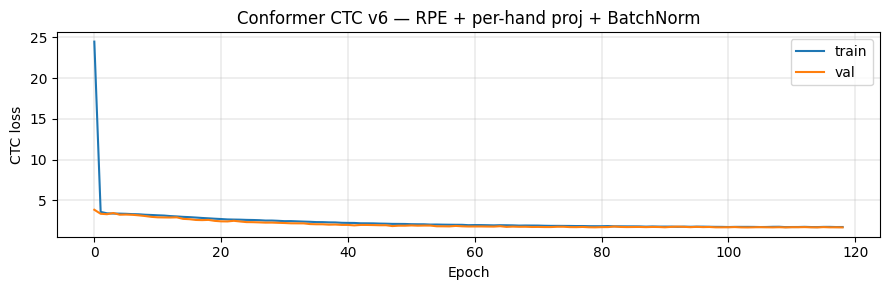

In [ ]:
# Final evaluation
def eval_cer(Xl, Xr, tgt_list, label=''):
    cer = greedy_decode_cer(Xl, Xr, tgt_list)
    print(f'{label:8s}  CER: {cer:.3f}  ({cer*100:.1f}%)')
    return cer

model.eval()
print('\n── Final evaluation ──')
eval_cer(Xl_val,  Xr_val,  tgt_val,  label='val')
eval_cer(Xl_test, Xr_test, tgt_test, label='test')

# Val samples
print('\n── Val samples ──')
with torch.no_grad():
    for i in range(min(5, len(Xl_val))):
        lp  = F.log_softmax(model(Xl_val[i:i+1].to(device), Xr_val[i:i+1].to(device)), dim=-1)[0].cpu()
        tokens = lp.argmax(-1).tolist()
        pred, prev = [], None
        for t in tokens:
            if t != blank_id and t != prev: pred.append(CHARSET.label_to_key(t))
            prev = t
        true = [CHARSET.label_to_key(t.item()) for t in tgt_val[i]]
        print(f'  true={true}')
        print(f'  pred={pred}\n')

# Loss curve
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('CTC loss')
ax.set_title('Conformer CTC v6 — RPE + per-hand proj + BatchNorm')
ax.legend(); ax.grid(True, lw=0.3)
plt.tight_layout(); plt.show()
